In [5]:
# Import packages
import os
from pathlib import Path

os.chdir(Path.cwd().parent)
project_dir = Path("/home/mcaskey/10XvParse/")
analysis_name="Analysis_2"

import matplotlib.pyplot as plt
from XvP_utils import plotting

In [6]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Preprocess

In [ ]:
kb_dir = project_dir / f"Data/{analysis_name}/parse_mini/kb_python/parse_out"
polyT_bcs_file = project_dir / f"Configs/{analysis_name}/parse_mini/r1_T.txt"
rando_bcs_file = project_dir / f"Configs/{analysis_name}/parse_mini/r1_R.txt"
replacement_bcs_file = project_dir / f"Configs/{analysis_name}/parse_mini/replace.txt"
bc_to_wells_file = project_dir / f"Configs/{analysis_name}/parse_mini/bcs_to_wells.txt"

In [14]:
# load data
parse_data = plotting.init_processing(analysis_name=analysis_name, project_dir=project_dir, data_name='parse', assay="parse_mini", data_title='Parse', modified=True)
unmodified_data = plotting.init_processing(analysis_name=analysis_name, project_dir=project_dir, data_name='parse', assay="parse_mini", data_title='Parse', modified=False)

In [15]:
# count in polyT and randO barcodes and extract the corresponding data from the unmodified data
with open(polyT_bcs_file, 'r') as f:
    polyT_bcs = [line.strip() for line in f]
with open(rando_bcs_file, 'r') as f:
    rando_bcs = [line.strip() for line in f]

polyT_data = unmodified_data[unmodified_data.obs_names.str.endswith(tuple(polyT_bcs))]
randO_data = unmodified_data[unmodified_data.obs_names.str.endswith(tuple(rando_bcs))]

# replace randO barcodes with polyT barcodes in randO data
with open(replacement_bcs_file, 'r') as f:
    for line in f:
        rando_bc, polyT_bc = line.strip().split()
        randO_data.obs_names = randO_data.obs_names.str.replace(f"{rando_bc}$", polyT_bc[1:], regex=True)

# Add well information to the data
bc_to_wells = {}
with open(bc_to_wells_file, 'r') as f:
    for line in f:
        bc, well = line.strip().split()
        bc_to_wells[bc] = well

randO_data.obs['well'] = randO_data.obs_names.str[-8:].map(bc_to_wells)
polyT_data.obs['well'] = polyT_data.obs_names.str[-8:].map(bc_to_wells)
parse_data.obs['well'] = parse_data.obs_names.str[-8:].map(bc_to_wells)

/tmp/ipykernel_1734224/2992652321.py:24: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  polyT_data.obs['well'] = polyT_data.obs_names.str[-8:].map(bc_to_wells)


In [16]:
# Add polyT and randO count counts to parse data
parse_data.obs['polyT_counts'] = 0
parse_data.obs.loc[polyT_data.obs_names, 'polyT_counts'] = polyT_data.obs['n_counts']

parse_data.obs['randO_counts'] = 0
parse_data.obs.loc[randO_data.obs_names, 'randO_counts'] = randO_data.obs['n_counts']

# Parse Well Analysis

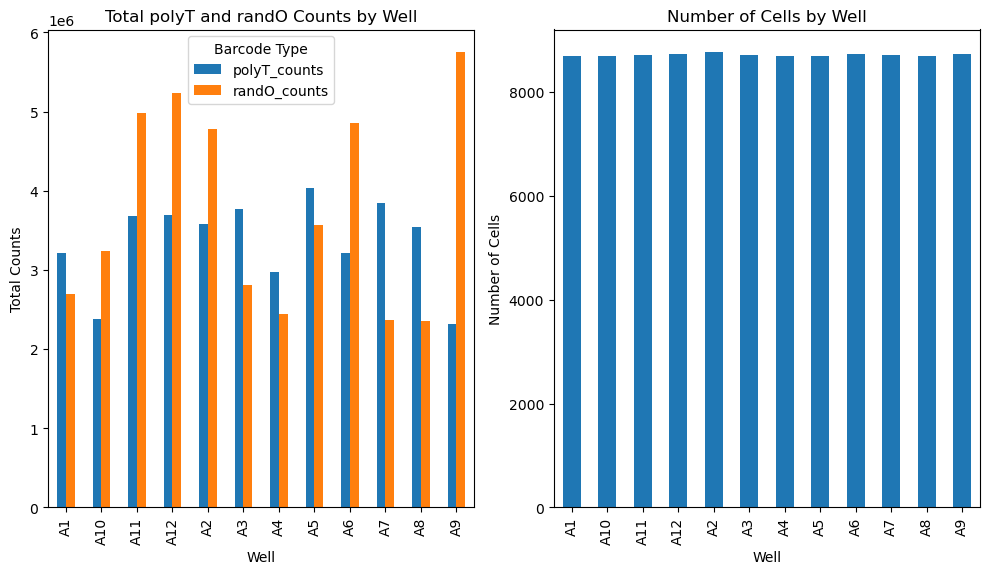

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(10, 6))

plotting.plot_counts_by_well(ax[0], parse_data)
plotting.plot_num_cells_by_well(ax[1], parse_data)

plt.tight_layout()
plt.show()

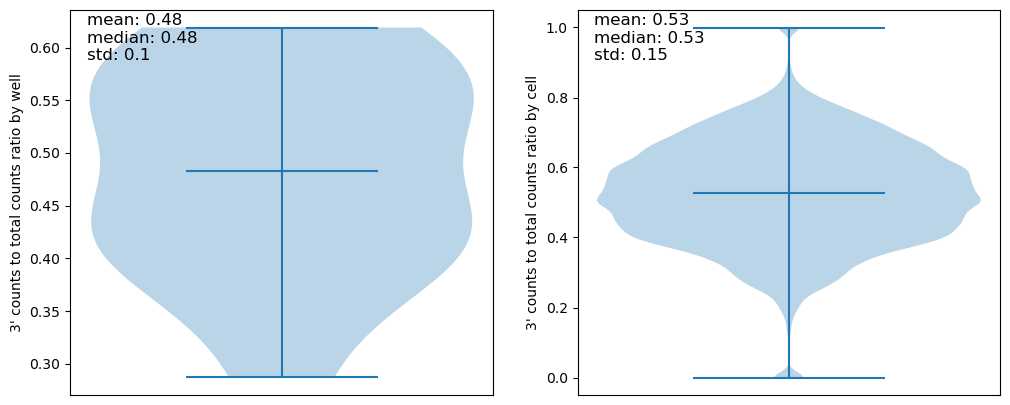

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

plotting.violin_by_well(ax[0], parse_data.obs)
plotting.violin_by_cell(ax[1], parse_data.obs)

plt.show()

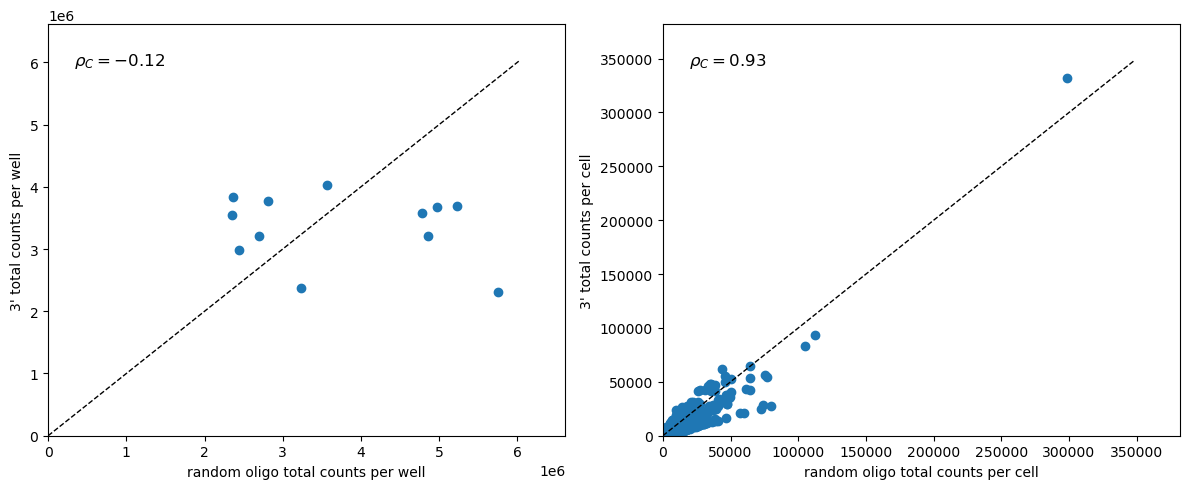

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

plotting.plot_by_well(ax[0], parse_data.obs)
plotting.plot_by_cell(ax[1], parse_data.obs)

plt.tight_layout()
plt.show()

19,191 cells passed the 400 UMI threshold for Parse


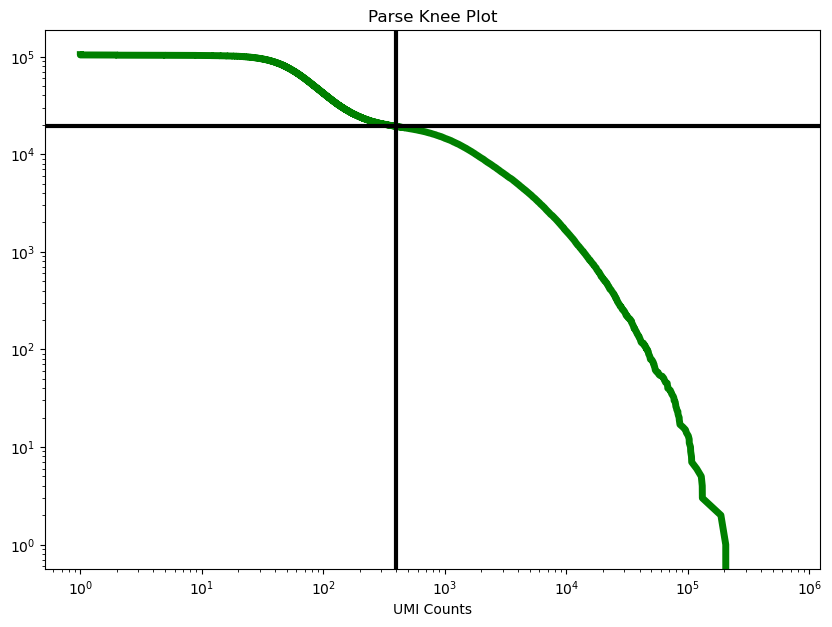

In [ ]:
parse_filtered = plotting.knee_plot([parse_data], cutoffs = [400], figsize=(10,7))[0]

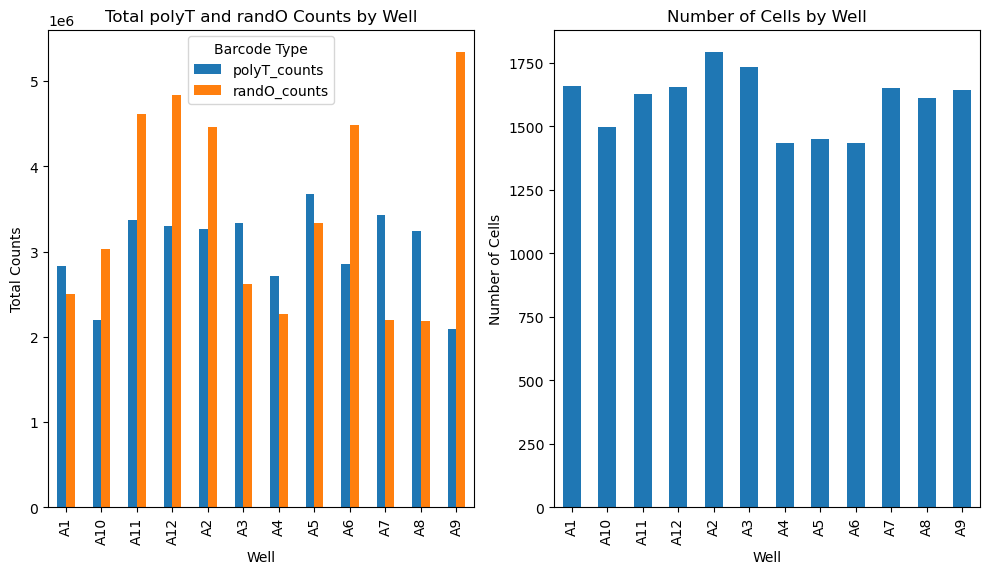

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(10, 6))
# Plot counts by well
plotting.plot_counts_by_well(ax[0], parse_filtered)
# Plot number of cells by well
plotting.plot_num_cells_by_well(ax[1], parse_filtered)

plt.tight_layout()
plt.show()

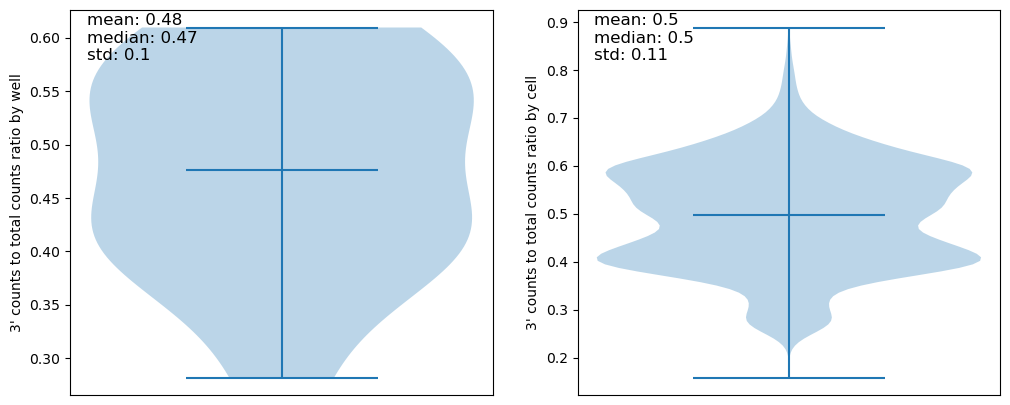

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

plotting.violin_by_well(ax[0], parse_filtered.obs)
plotting.violin_by_cell(ax[1], parse_filtered.obs)

plt.show()

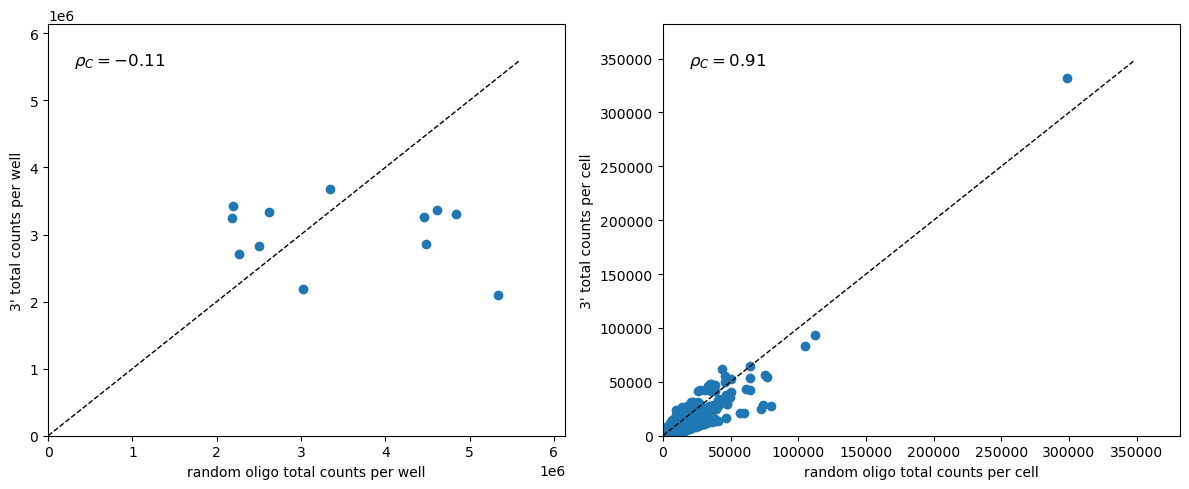

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

plotting.plot_by_well(ax[0], parse_filtered.obs)
plotting.plot_by_cell(ax[1], parse_filtered.obs)

plt.tight_layout()
plt.show()